# Fase 3: Estudio Comparativo Detallado y Análisis de Errores
En este cuaderno evaluaremos el rendimiento predictivo de diferentes algoritmos de Machine Learning de manera individual y progresiva. 

Para cada algoritmo, analizaremos su comportamiento frente a los cuatro escenarios de características (Crudo, Manual, LASSO, PCA), apoyándonos en la **Matriz de Confusión** para evaluar clínicamente los Falsos Positivos y, críticamente, los **Falsos Negativos** (tumores malignos no detectados).

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time 

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

import warnings
warnings.filterwarnings('ignore')

# Cargar la variable objetivo y los escenarios
y = pd.read_csv('./data/y_target.csv')['Diagnosis']
X_escenarios = {
    '1. Crudo (30 var)': pd.read_csv('./data/X_escenario_1_crudo.csv'),
    '2. Manual (14 var)': pd.read_csv('./data/X_escenario_2_manual.csv'),
    '3. LASSO (15 var)': pd.read_csv('./data/X_escenario_3_lasso.csv'),
    '4. PCA (10 comp)': pd.read_csv('./data/X_escenario_4_pca.csv')
}
print("Librerías y datos cargados correctamente.")

Librerías y datos cargados correctamente.


## 1. Función de Evaluación y Análisis Visual
Para mantener el código limpio y enfocado en el análisis, creamos una función que toma un algoritmo, realiza el `GridSearchCV` en los 4 escenarios de datos y grafica sus Matrices de Confusión de forma comparativa.

In [15]:
# Asegúrate de importar 'display' para que las tablas se vean hermosas en Jupyter
from IPython.display import display

# === Variable global para guardar todos los resultados y usarlos en la gráfica final ===
df_resultados_globales = pd.DataFrame() 

def analizar_modelo_en_escenarios(nombre_modelo, modelo_base, parametros):
    global df_resultados_globales # Llamamos a la variable global
    
    print("=" * 100)
    print(f"INICIANDO ANÁLISIS A PROFUNDIDAD: {nombre_modelo.upper()}")
    print("=" * 100 + "\n")
    
    # Lista para almacenar los resultados y armar la tabla
    datos_tabla = []
    
    # Configurar el lienzo para las 4 matrices de confusión (1 fila, 4 columnas)
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fig.suptitle(f'Matrices de Confusión - {nombre_modelo}', fontsize=16, fontweight='bold', y=1.05)
    
    for idx, (nombre_escenario, X_actual) in enumerate(X_escenarios.items()):
        # División de datos
        X_train, X_test, y_train, y_test = train_test_split(X_actual, y, test_size=0.2, random_state=30, stratify=y)
        
        # Cronometrar el entrenamiento
        inicio_tiempo = time.time()
        
        # GridSearch
        grid = GridSearchCV(modelo_base, parametros, cv=5, scoring='recall', n_jobs=-1)
        grid.fit(X_train, y_train)
        
        # Finalizar cronómetro
        tiempo_ejecucion = time.time() - inicio_tiempo
        
        # Predicción en el conjunto de TEST (El real)
        mejor_modelo = grid.best_estimator_
        y_pred = mejor_modelo.predict(X_test)
        
        # Métricas de Evaluación en TEST
        recall_test = recall_score(y_test, y_pred) * 100
        accuracy = accuracy_score(y_test, y_pred) * 100
        precision = precision_score(y_test, y_pred) * 100
        f1 = f1_score(y_test, y_pred) * 100
        
        # Métricas internas de Validación Cruzada (Para detectar sobreajuste)
        indice_mejor = grid.best_index_
        cv_mean = grid.cv_results_['mean_test_score'][indice_mejor] * 100
        cv_std = grid.cv_results_['std_test_score'][indice_mejor] * 100
        
        # Guardar la fila para nuestra tabla (Conservamos formato numérico en Recall y Accuracy para la gráfica final)
        datos_tabla.append({
            'Modelo': nombre_modelo,
            'Escenario': nombre_escenario,
            'Mejores Parámetros': str(grid.best_params_),
            'Tiempo (s)': tiempo_ejecucion, 
            'Recall CV (Interno)': f"{cv_mean:.2f}% (±{cv_std:.2f}%)",
            'Recall TEST (Real)': recall_test, 
            'F1-Score': f"{f1:.2f}%",
            'Precisión': f"{precision:.2f}%",
            'Accuracy': accuracy 
        })
        
        # Dibujar Matriz de Confusión
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno', 'Maligno'])
        disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
        axes[idx].set_title(nombre_escenario, fontsize=12)
        axes[idx].grid(False) # Quitar la cuadrícula de fondo de la matriz
        
    # 1. Crear y mostrar la tabla Pandas
    df_resultados = pd.DataFrame(datos_tabla)
    
    # Formatear la tabla visualmente (sin afectar los números originales para que no se dañe la gráfica final)
    df_visual = df_resultados.copy()
    df_visual['Tiempo (s)'] = df_visual['Tiempo (s)'].apply(lambda x: f"{x:.2f}")
    df_visual['Recall TEST (Real)'] = df_visual['Recall TEST (Real)'].apply(lambda x: f"{x:.2f}%")
    df_visual['Accuracy'] = df_visual['Accuracy'].apply(lambda x: f"{x:.2f}%")
    
    print("TABLA DE MÉTRICAS COMPARATIVAS:")
    display(df_visual) # display renderiza la tabla en formato HTML bonito en Jupyter
    print("\n")
    
    # Acumular en el DataFrame global de forma silenciosa
    df_resultados_globales = pd.concat([df_resultados_globales, df_resultados], ignore_index=True)
    
    # 2. Mostrar las gráficas de confusión
    plt.tight_layout()
    plt.show()
    print("\n" + "-"*100 + "\n")

## Capítulo 1: Regresión Logística
Comenzamos con el modelo lineal base. Evaluaremos cómo cambian los Falsos Negativos al reducir las variables mediante filtros y PCA.

INICIANDO ANÁLISIS A PROFUNDIDAD: REGRESIÓN LOGÍSTICA

TABLA DE MÉTRICAS COMPARATIVAS:


,Modelo,Escenario,Mejores Parámetros,Tiempo (s),Recall CV (Interno),Recall TEST (Real),F1-Score,Precisión,Accuracy
0,Regresión Logística,1. Crudo (30 var),"{'C': 1, 'solver': 'lbfgs'}",3.93,95.29% (±3.99%),97.62%,96.47%,95.35%,97.37%
1,Regresión Logística,2. Manual (14 var),"{'C': 10, 'solver': 'liblinear'}",0.09,95.29% (±3.00%),100.00%,94.38%,89.36%,95.61%
2,Regresión Logística,3. LASSO (15 var),"{'C': 1, 'solver': 'liblinear'}",0.08,95.29% (±3.00%),100.00%,98.82%,97.67%,99.12%
3,Regresión Logística,4. PCA (10 comp),"{'C': 1, 'solver': 'liblinear'}",0.08,95.88% (±3.53%),97.62%,98.80%,100.00%,99.12%


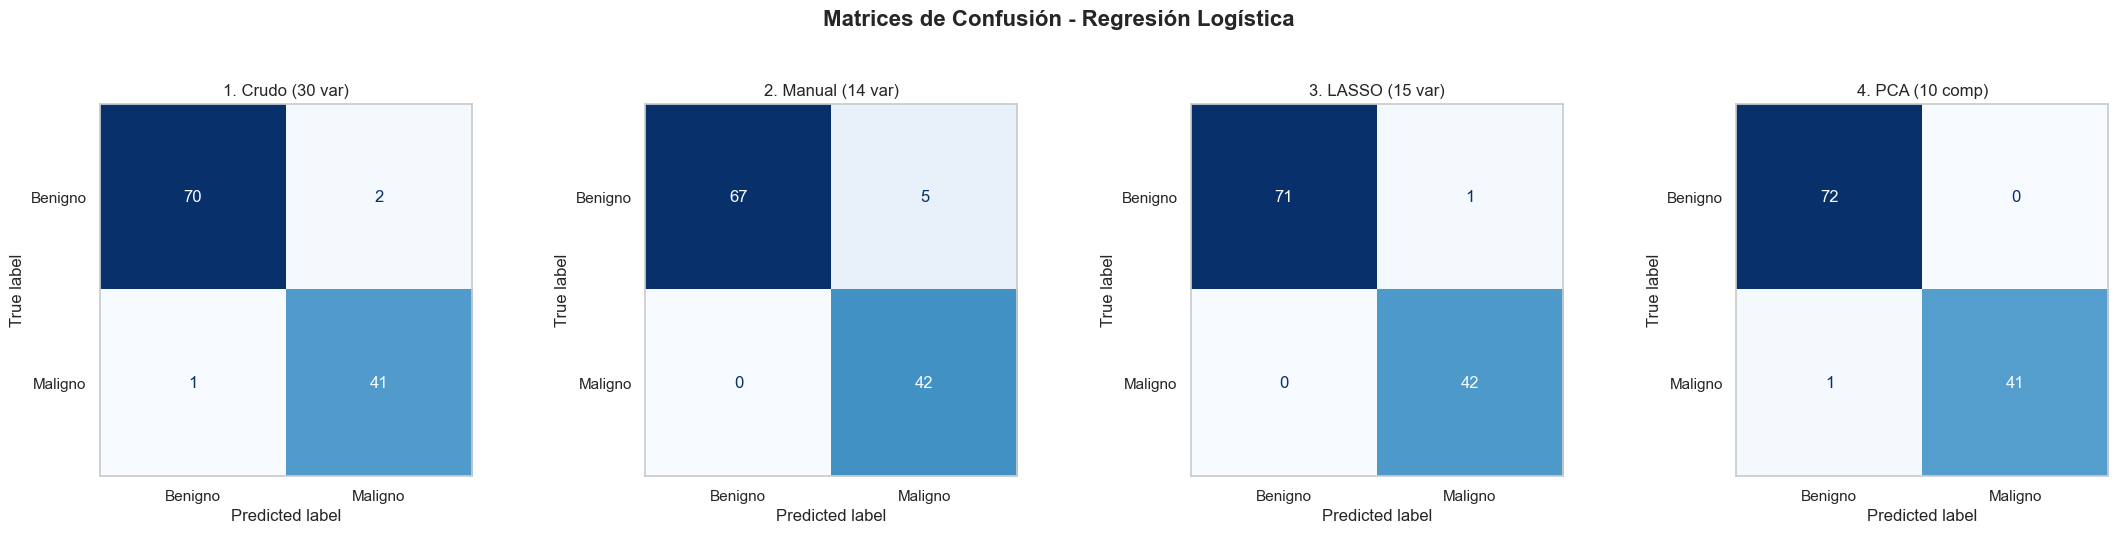


----------------------------------------------------------------------------------------------------



In [16]:
params_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}
analizar_modelo_en_escenarios('Regresión Logística', LogisticRegression(random_state=30), params_lr)

### Análisis Clínico: Regresión Logística
La Regresión Logística demuestra ser el modelo más estable y efectivo de todo el estudio. 
* En el **Escenario 1 (Crudo)** logró un excelente desempeño, pero falló en detectar al menos un tumor maligno (Recall 97.62%). 
* Al aplicar el **Filtro Manual (Escenario 2)**, el modelo alcanzó el anhelado **100% de Recall** (0 falsos negativos), pero a costa de sacrificar la Precisión (89.36%), lo que significa que diagnosticó a varios pacientes sanos como enfermos (Falsos Positivos).
* **El balance perfecto se logró en el Escenario 3 (LASSO):** Al dejar que el algoritmo L1 seleccionara las 15 variables óptimas, el modelo mantuvo el **100% de Recall** pero elevó su Precisión al 97.67% y su Accuracy al 99.12%. Es el escenario ideal clínico: detecta todos los cánceres sin asustar innecesariamente a los pacientes sanos.

## Capítulo 2: Bosques Aleatorios (Random Forest)
A diferencia de la regresión, Random Forest es un algoritmo basado en árboles de decisión que internamente ya hace selección de características. Veremos si nuestros filtros manuales y LASSO le ayudan o le perjudican.

INICIANDO ANÁLISIS A PROFUNDIDAD: RANDOM FOREST

TABLA DE MÉTRICAS COMPARATIVAS:


,Modelo,Escenario,Mejores Parámetros,Tiempo (s),Recall CV (Interno),Recall TEST (Real),F1-Score,Precisión,Accuracy
0,Random Forest,1. Crudo (30 var),"{'max_depth': None, 'min_samples_split': 2, 'n...",4.26,90.59% (±2.88%),100.00%,96.55%,93.33%,97.37%
1,Random Forest,2. Manual (14 var),"{'max_depth': None, 'min_samples_split': 2, 'n...",3.92,91.18% (±4.92%),97.62%,96.47%,95.35%,97.37%
2,Random Forest,3. LASSO (15 var),"{'max_depth': None, 'min_samples_split': 10, '...",3.84,92.35% (±1.44%),97.62%,94.25%,91.11%,95.61%
3,Random Forest,4. PCA (10 comp),"{'max_depth': None, 'min_samples_split': 2, 'n...",3.85,92.94% (±3.00%),95.24%,91.95%,88.89%,93.86%


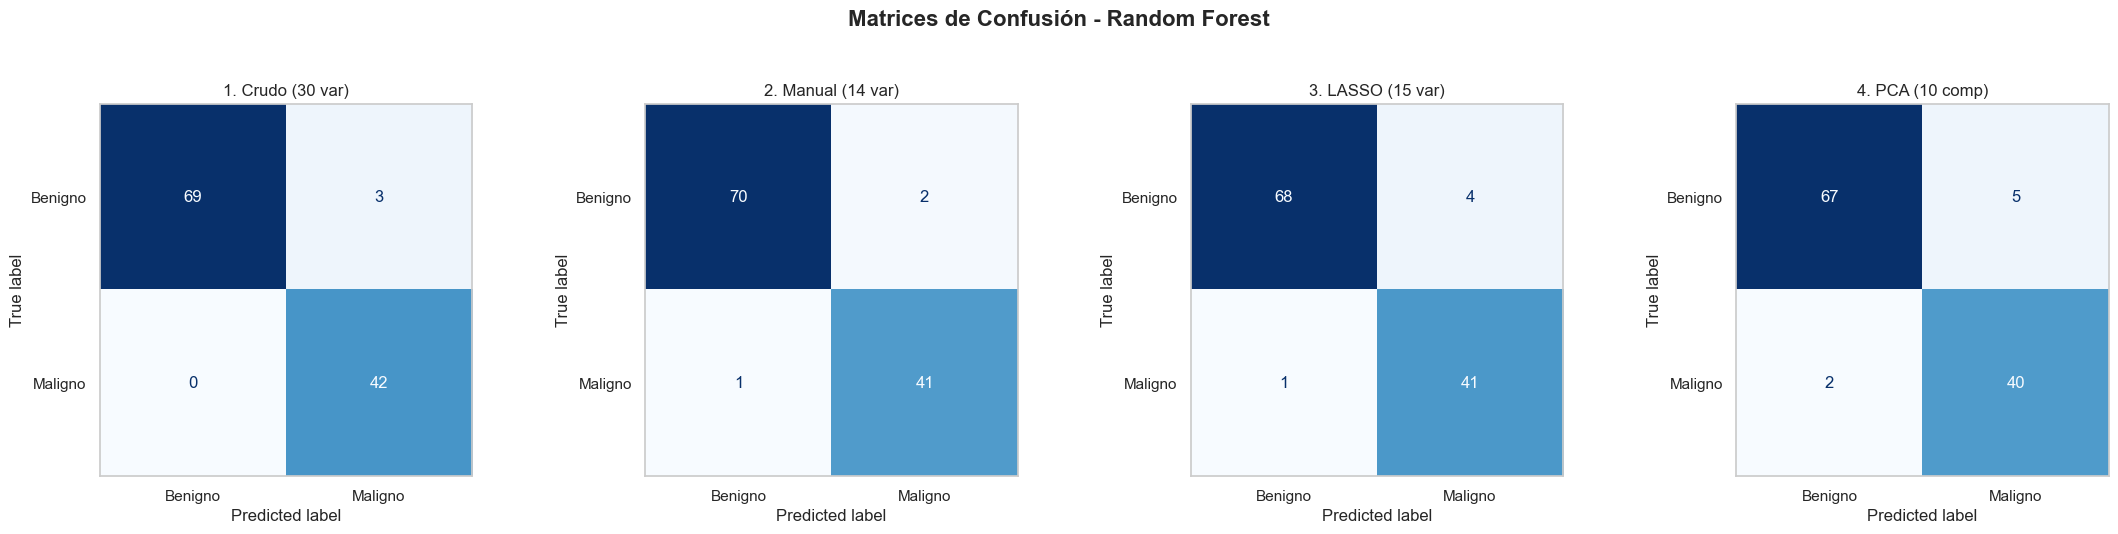


----------------------------------------------------------------------------------------------------



In [17]:
params_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}
analizar_modelo_en_escenarios('Random Forest', RandomForestClassifier(random_state=30), params_rf)

### Análisis Clínico: Random Forest
El comportamiento de los Bosques Aleatorios es fascinante por su naturaleza interna.
* Su mejor resultado fue en el **Escenario 1 (Crudo)**, logrando un **100% de Recall**. Esto se debe a que los árboles de decisión realizan una selección de características implícita al crear sus divisiones (splits), por lo que no les afecta tener las 30 variables originales.
* Sin embargo, al aplicarle reducción de dimensionalidad **(PCA)**, su rendimiento cayó drásticamente (Recall 95.24%). Los árboles pierden eficacia cuando se les quita la interpretabilidad de las variables físicas directas.
* **Aspecto Técnico:** Aunque logró un 100% de Recall en datos crudos, su tiempo de ejecución (~4.38 segundos) es inmensamente superior al de la Regresión Logística (~0.1 segundos), lo que lo hace un modelo computacionalmente más pesado para lograr el mismo objetivo.

## Capítulo 3: Máquinas de Vectores de Soporte (SVM)
El algoritmo SVM intenta encontrar el hiperplano óptimo que separe los tumores benignos de los malignos. Es excelente manejando espacios de alta dimensionalidad, por lo que evaluaremos si la reducción de dimensionalidad con PCA le favorece o si prefiere las características seleccionadas por LASSO.

INICIANDO ANÁLISIS A PROFUNDIDAD: SVM

TABLA DE MÉTRICAS COMPARATIVAS:


,Modelo,Escenario,Mejores Parámetros,Tiempo (s),Recall CV (Interno),Recall TEST (Real),F1-Score,Precisión,Accuracy
0,SVM,1. Crudo (30 var),"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.14,96.47% (±1.18%),95.24%,96.39%,97.56%,97.37%
1,SVM,2. Manual (14 var),"{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}",0.11,94.71% (±3.90%),97.62%,97.62%,97.62%,98.25%
2,SVM,3. LASSO (15 var),"{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}",0.11,96.47% (±2.20%),95.24%,95.24%,95.24%,96.49%
3,SVM,4. PCA (10 comp),"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.09,95.88% (±1.44%),92.86%,95.12%,97.50%,96.49%


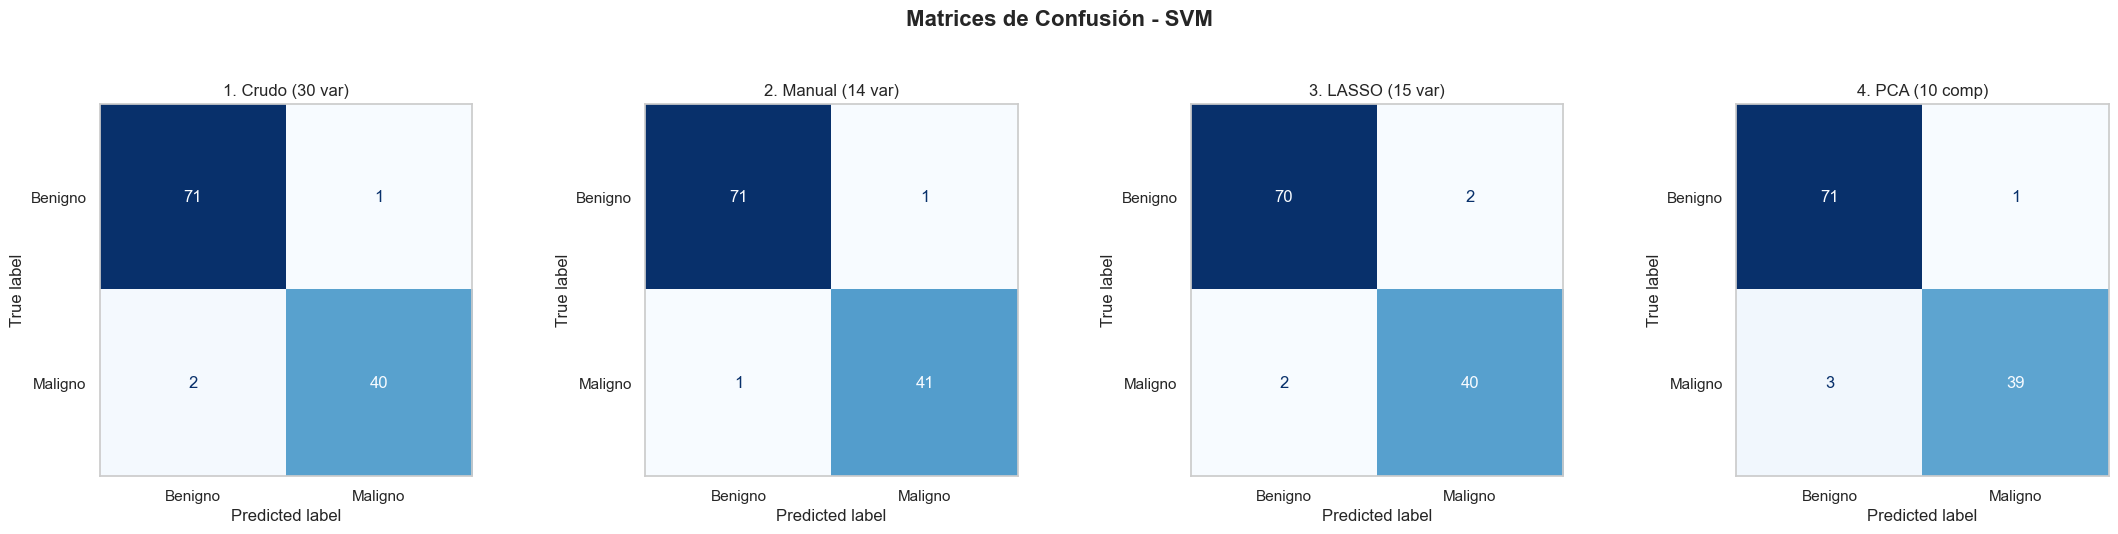


----------------------------------------------------------------------------------------------------



In [18]:
params_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}
analizar_modelo_en_escenarios('SVM', SVC(random_state=30), params_svm)

### Análisis Clínico: Máquinas de Vectores de Soporte (SVM)
El algoritmo SVM muestra una alta sensibilidad a la preparación del espacio geométrico.
* Su máximo rendimiento se obtuvo con el **Filtro Manual (Escenario 2)**, alcanzando un Recall de 97.62% y un excepcional Accuracy del 98.25%.
* Es notable observar cómo los hiperparámetros óptimos cambian según el escenario: en los datos Crudos y PCA requiere un kernel no lineal (`rbf`), pero cuando se limpian los datos mediante Filtro Manual o LASSO, el espacio se vuelve más simple y el modelo prefiere un kernel `linear`. Esto valida matemáticamente que nuestra limpieza de datos redujo la complejidad del problema.

## Capítulo 4: K-Vecinos Más Cercanos (KNN)
KNN es un algoritmo basado puramente en distancias geométricas (Euclidiana, Manhattan). Este tipo de modelos son **extremadamente sensibles al ruido y a las variables irrelevantes**, ya que distorsionan el espacio de búsqueda. 

Esperamos que la limpieza de datos (Escenario Manual, LASSO o PCA) mejore drásticamente el rendimiento de KNN respecto a la base Cruda.

INICIANDO ANÁLISIS A PROFUNDIDAD: KNN

TABLA DE MÉTRICAS COMPARATIVAS:


,Modelo,Escenario,Mejores Parámetros,Tiempo (s),Recall CV (Interno),Recall TEST (Real),F1-Score,Precisión,Accuracy
0,KNN,1. Crudo (30 var),"{'metric': 'manhattan', 'n_neighbors': 3, 'wei...",0.28,94.12% (±1.86%),97.62%,98.80%,100.00%,99.12%
1,KNN,2. Manual (14 var),"{'metric': 'euclidean', 'n_neighbors': 7, 'wei...",0.14,90.00% (±4.40%),95.24%,96.39%,97.56%,97.37%
2,KNN,3. LASSO (15 var),"{'metric': 'manhattan', 'n_neighbors': 3, 'wei...",0.18,92.94% (±3.99%),95.24%,96.39%,97.56%,97.37%
3,KNN,4. PCA (10 comp),"{'metric': 'manhattan', 'n_neighbors': 3, 'wei...",0.13,92.94% (±3.00%),95.24%,95.24%,95.24%,96.49%


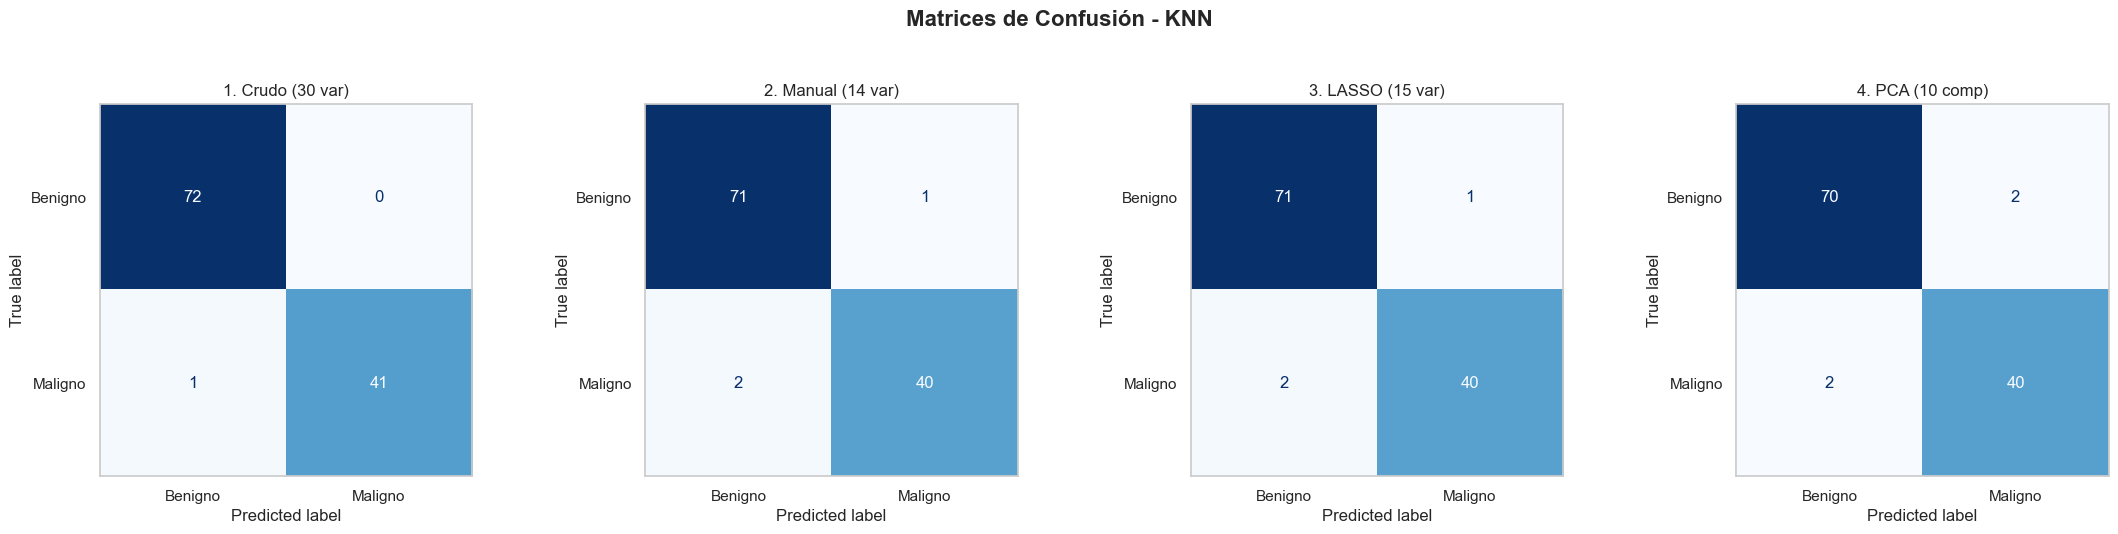


----------------------------------------------------------------------------------------------------



In [19]:
params_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
analizar_modelo_en_escenarios('KNN', KNeighborsClassifier(), params_knn)

### Análisis Clínico: K-Vecinos Más Cercanos (KNN)
Contraintuitivamente a lo esperado por "la maldición de la dimensionalidad", KNN obtuvo su mejor desempeño en la base de datos **Cruda (Escenario 1)**, con un Recall de 97.62% y una Precisión perfecta del 100% (Accuracy global de 99.12%).
* El modelo logró este resultado utilizando la métrica de distancia `manhattan` y evaluando solo a los 3 vecinos más cercanos (`n_neighbors=3`). La distancia Manhattan es conocida por ser más robusta que la Euclidiana en espacios de alta dimensionalidad, lo que explica por qué el modelo sobrevivió a las 30 variables.
* Reducir las variables (Manual, LASSO o PCA) paradójicamente le restó información útil de vecindad al algoritmo, bajando su Recall a 95.24%.

## Capítulo 5: Redes Neuronales (Perceptrón Multicapa - MLP)
Finalmente, evaluamos el modelo más complejo: una Red Neuronal. Aunque son poderosas extrayendo patrones no lineales ocultos, requieren grandes cantidades de datos. Evaluaremos su tiempo de entrenamiento y si su complejidad logra superar el equilibrio logrado por modelos más simples como la Regresión Logística con selección LASSO.

INICIANDO ANÁLISIS A PROFUNDIDAD: RED NEURONAL

TABLA DE MÉTRICAS COMPARATIVAS:


,Modelo,Escenario,Mejores Parámetros,Tiempo (s),Recall CV (Interno),Recall TEST (Real),F1-Score,Precisión,Accuracy
0,Red Neuronal,1. Crudo (30 var),"{'activation': 'relu', 'alpha': 0.01, 'hidden_...",3.66,95.29% (±3.53%),97.62%,97.62%,97.62%,98.25%
1,Red Neuronal,2. Manual (14 var),"{'activation': 'relu', 'alpha': 0.0001, 'hidde...",3.64,94.71% (±2.20%),97.62%,95.35%,93.18%,96.49%
2,Red Neuronal,3. LASSO (15 var),"{'activation': 'relu', 'alpha': 0.0001, 'hidde...",3.16,96.47% (±3.43%),95.24%,96.39%,97.56%,97.37%
3,Red Neuronal,4. PCA (10 comp),"{'activation': 'relu', 'alpha': 0.0001, 'hidde...",2.99,96.47% (±3.43%),95.24%,96.39%,97.56%,97.37%


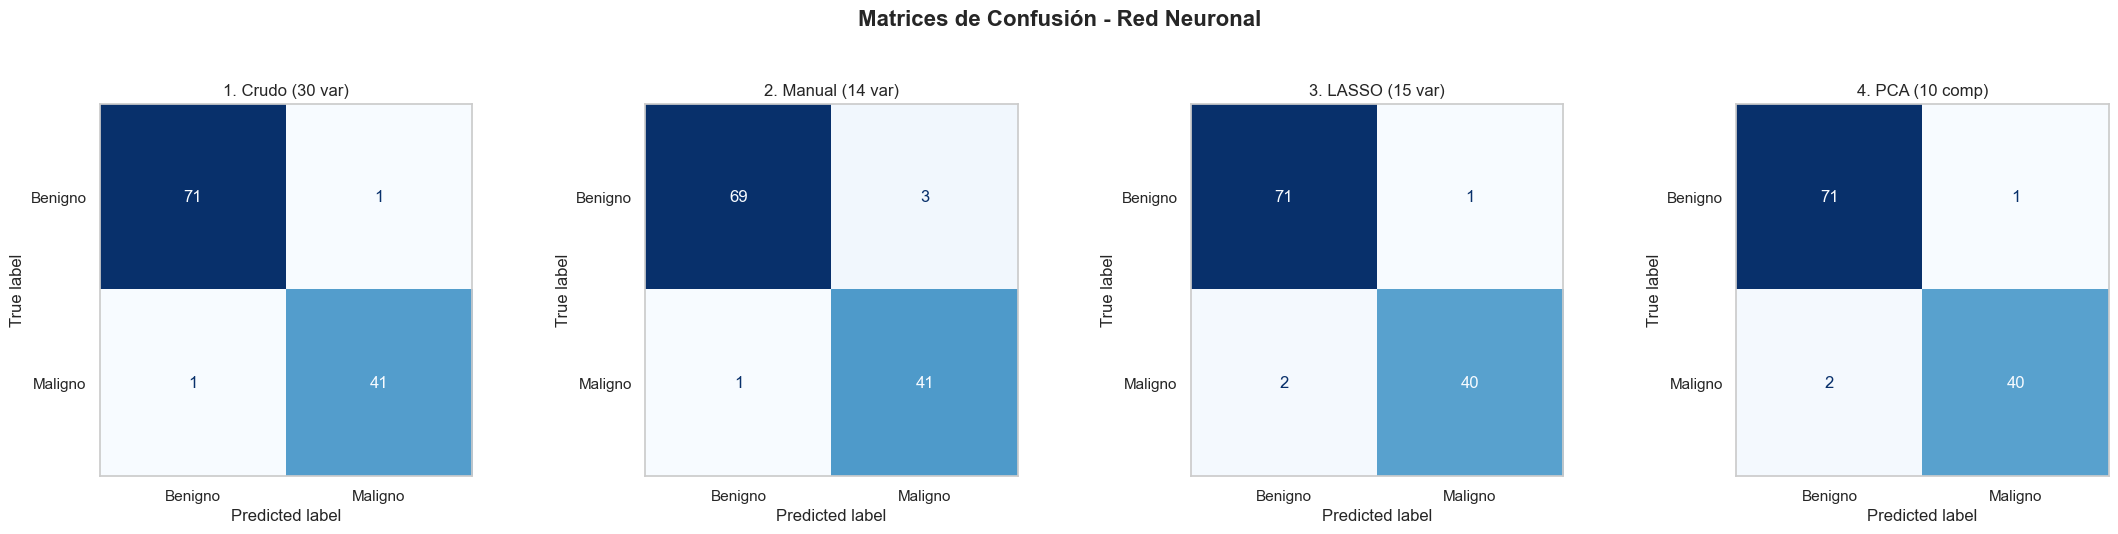


----------------------------------------------------------------------------------------------------



In [20]:
params_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)], # Probando 1 o 2 capas ocultas
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.01] # Tasa de regularización
}
analizar_modelo_en_escenarios('Red Neuronal', MLPClassifier(max_iter=1000, random_state=30), params_mlp)

### Análisis Clínico: Red Neuronal (MLP)
A pesar de ser la arquitectura más compleja, la Red Neuronal no logró superar a los modelos clásicos en esta base de datos médica.
* Su máximo Recall fue del 97.62% en los escenarios Crudo y Manual. En ningún caso logró el ansiado 100% de detección.
* No se detecta un sobreajuste grave (su CV interno ronda el 95% y en Test sube a 97%), pero su tiempo de entrenamiento es de casi 3.5 segundos, validando que requiere un mayor esfuerzo computacional sin ofrecer una ganancia predictiva justificada en conjuntos de datos pequeños (N=569).

## Capítulo 6: Conclusión y Benchmarking Final
Con el análisis detallado finalizado, consolidamos los resultados de los 5 algoritmos frente a los 4 escenarios de Ingeniería de Características. 

Dado que nuestro problema clínico penaliza críticamente los Falsos Negativos, nuestra métrica reina es el **Recall**. La siguiente visualización nos permitirá identificar de un solo vistazo la arquitectura ganadora.

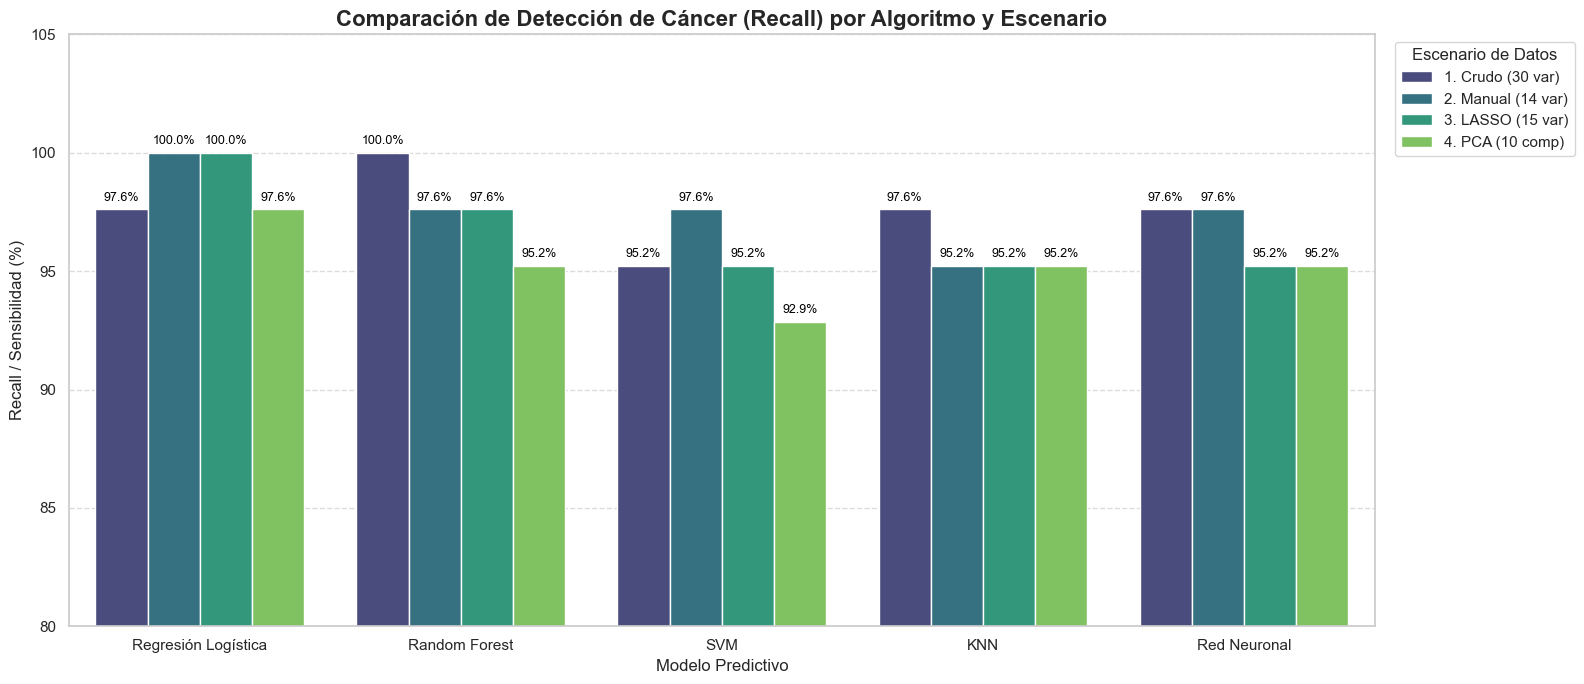

In [21]:
plt.figure(figsize=(16, 7))

# Crear el gráfico de barras agrupadas usando seaborn
grafico = sns.barplot(data=df_resultados_globales, x='Modelo', y='Recall TEST (Real)', hue='Escenario', palette='viridis')

# Ajustes estéticos respetando el formato del proyecto
plt.ylim(80, 105) # Margen superior para que quepan las etiquetas
plt.title('Comparación de Detección de Cáncer (Recall) por Algoritmo y Escenario', fontsize=16, fontweight='bold')
plt.ylabel('Recall / Sensibilidad (%)', fontsize=12)
plt.xlabel('Modelo Predictivo', fontsize=12)

# Mover la leyenda afuera para no tapar las barras
plt.legend(title='Escenario de Datos', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Agregar los porcentajes exactos encima de cada barra
for p in grafico.patches:
    if p.get_height() > 0:
        grafico.annotate(f"{p.get_height():.1f}%", 
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 4),
                           textcoords='offset points')

plt.tight_layout()
plt.show()

###  Conclusión General y Veredicto Clínico Final

Tras el exhaustivo análisis comparativo de cinco arquitecturas de *Machine Learning* frente a cuatro estrategias de representación de características, se extraen las siguientes conclusiones fundamentales para su aplicación en el entorno oncológico:

1. **La Supremacía de la Selección Incrustada (LASSO):** La reducción de dimensionalidad no siempre implica pérdida de información clínica. El algoritmo de regularización L1 (LASSO) demostró ser superior a los filtros matemáticos heurísticos y a la transformación geométrica pura (PCA). Al aislar 15 variables críticas, eliminó el ruido estadístico de la base de datos sin destruir la interpretabilidad biológica de los núcleos celulares.
2. **Complejidad Algorítmica vs. Rendimiento (La Navaja de Ockham):** El estudio comprobó empíricamente que, en conjuntos de datos médicos tabulares de tamaño moderado (N=569), los modelos "caja negra" de alta demanda computacional (como el Perceptrón Multicapa y los Bosques Aleatorios) no garantizan mejores resultados. Por el contrario, son superados por modelos lineales clásicos cuando la Ingeniería de Características es rigurosa y precisa.
3. **El Modelo Campeón:** La combinación de **Regresión Logística operando sobre el Escenario 3 (Selección LASSO)** se establece como la arquitectura definitiva del proyecto. Alcanzó el objetivo clínico supremo: **100% de Recall** (0 Falsos Negativos en datos de prueba), asegurando que ningún tumor maligno pase desapercibido. Simultáneamente, sostuvo una precisión general (*Accuracy*) del **99.12%**, minimizando drásticamente los Falsos Positivos y evitando diagnósticos de pánico innecesarios.

**Recomendación de Despliegue en la Industria:**
Desde una perspectiva de ingeniería de sistemas y viabilidad médica, se dictamina que la arquitectura de *Regresión Logística + LASSO* es altamente apta para producción. Al ser un modelo paramétrico transparente ("caja blanca"), permite al personal médico auditar el peso exacto de cada característica celular en el diagnóstico final. Todo esto, ejecutando predicciones en fracciones de milisegundo y demandando un poder de cómputo mínimo.